# 1.2 Reddit: Network Analysis

This notebook analyses the structural relationships between Reddit subreddits and candidate-buzz clusters using the **silver-layer** cleaned data.

Three complementary network perspectives:
1. **Subreddit overlap network** — subreddits as nodes, Jaccard author-overlap as edges
2. **Keyword similarity network** — subreddits connected by TF-IDF cosine similarity of their vocabulary
3. **Candidate-buzz flow** — cross-cluster echo-chamber analysis (TrumpBuzz / HarrisBuzz / ElectionBuzz)

**Input:** `Data/2_Silver/Reddit/reddit_posts_clean.parquet` · `reddit_comments_clean.parquet`


<!-- toc -->
## Contents
- **[1. Setup](#1-setup)**
- **[2. Load Data](#2-load-data)**
- **[3. Subreddit Overlap Network](#3-subreddit-overlap-network)**
- **[4. Cross-subreddit Author Activity](#4-cross-subreddit-author-activity)**
- **[5. Keyword Similarity Network](#5-keyword-similarity-network)**
- **[6. Candidate Buzz Flow](#6-candidate-buzz-flow)**
- **[7. Summary](#7-summary)**


## 1. Setup


In [22]:
import sys
sys.path.insert(0, '../..')
from house_style import (
    apply_style, styled_fig, style_ax,
    BG_DARK, BG_PANEL, REPUBLICAN, DEMOCRAT, NEUTRAL,
    TEXT_PRIMARY, TEXT_MUTED, GRID_COLOR, SPINE_COLOR, PALETTE,
    BUZZ_COLORS,C_VIX,C_SP500,C_FEAR,C_ANGER,C_TRUST,C_DISGUST,
    C_SADNESS,C_JOY,C_ANTICIPATION,
)
apply_style()

from pathlib import Path
from collections import Counter
import ast

import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

DATA_DIR = Path('../../Data/2_Silver/Reddit')

# Political leaning per subreddit (manual assignment)
LEANING = {
    'conservative': 'right',
    'trump':        'right',
    'republican':   'right',
    'politics':     'center',
    'worldnews':    'center',
    'democrats':    'left',
    'liberal':      'left',
}

# Colour per political leaning
LEANING_COLORS = {
    'left':   DEMOCRAT,
    'right':  REPUBLICAN,
    'center': NEUTRAL,
}

# Colour per subreddit
SUBREDDIT_COLORS = {
    'conservative': REPUBLICAN,
    'trump':        '#c0392b',
    'republican':   '#e07b39',
    'politics':     '#f39c12',
    'worldnews':    '#2ecc71',
    'democrats':    DEMOCRAT,
    'liberal':      '#5dade2',
}

## 2. Load Data


In [23]:
# Load silver posts and comments
posts    = pd.read_parquet(DATA_DIR / 'reddit_posts_clean.parquet')
comments = pd.read_parquet(DATA_DIR / 'reddit_comments_clean.parquet')

# Remove deleted / bot accounts
BOTS = {'[deleted]', 'AutoModerator', 'BotDefense', 'RemindMeBot'}
posts    = posts[~posts['author'].isin(BOTS)]
comments = comments[~comments['author'].isin(BOTS)]

print(f'Posts    : {len(posts):>9,}  |  subreddits: {posts["subreddit"].nunique()}')
print(f'Comments : {len(comments):>9,}  |  subreddits: {comments["subreddit"].nunique()}')
print()
print('Posts per subreddit:')
print(posts['subreddit'].value_counts().to_string())
print()
print('Candidate distribution (posts):')
print(posts['candidate'].value_counts().to_string())


Posts    :   103,008  |  subreddits: 7
Comments : 1,321,876  |  subreddits: 7

Posts per subreddit:
subreddit
politics        49160
conservative    20761
democrats       13203
trump            9340
republican       5378
worldnews        4112
liberal          1054

Candidate distribution (posts):
candidate
TrumpBuzz       42146
HarrisBuzz      36297
ElectionBuzz    24565


## 3. Subreddit Overlap Network


Subreddits are modelled as **nodes**. Two subreddits are connected if their author sets overlap.  
Edge weight = **Jaccard similarity**: |A ∩ B| / |A ∪ B|, so values range from 0 (no shared authors) to 1 (identical author sets).  
This gives a *unipartite* subreddit–subreddit graph built from the underlying bipartite author–subreddit graph.


In [24]:
# Combine posts + comments to get full author-subreddit co-occurrence
author_sub = pd.concat([
    posts[['author', 'subreddit']],
    comments[['author', 'subreddit']],
]).drop_duplicates()

# Build author sets per subreddit
subs = sorted(author_sub['subreddit'].unique())
sub_authors = {s: set(author_sub[author_sub['subreddit'] == s]['author']) for s in subs}

# Jaccard matrix
n = len(subs)
J = np.zeros((n, n))
for i, s1 in enumerate(subs):
    for j, s2 in enumerate(subs):
        inter = len(sub_authors[s1] & sub_authors[s2])
        union = len(sub_authors[s1] | sub_authors[s2])
        J[i, j] = inter / union if union > 0 else 0

J_df = pd.DataFrame(J, index=subs, columns=subs)

print('Jaccard similarity matrix (author overlap):')
print(J_df.round(3).to_string())


Jaccard similarity matrix (author overlap):
              conservative  democrats  liberal  politics  republican  trump  worldnews
conservative         1.000      0.019    0.005     0.034       0.051  0.039      0.020
democrats            0.019      1.000    0.032     0.058       0.016  0.009      0.032
liberal              0.005      0.032    1.000     0.005       0.006  0.003      0.003
politics             0.034      0.058    0.005     1.000       0.006  0.006      0.078
republican           0.051      0.016    0.006     0.006       1.000  0.051      0.003
trump                0.039      0.009    0.003     0.006       0.051  1.000      0.004
worldnews            0.020      0.032    0.003     0.078       0.003  0.004      1.000


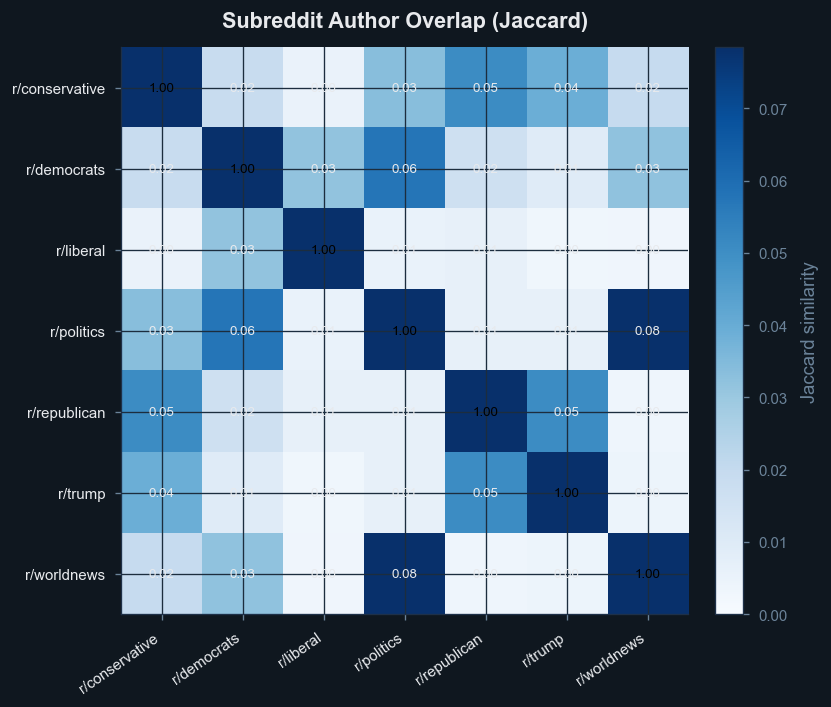

In [25]:
# --- Heatmap ---
fig, ax = styled_fig(figsize=(7, 6))

im = ax.imshow(J, cmap='Blues', vmin=0, vmax=J[J < 1].max())

ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels([f'r/{s}' for s in subs], rotation=35, ha='right', color=TEXT_PRIMARY, fontsize=9)
ax.set_yticklabels([f'r/{s}' for s in subs], color=TEXT_PRIMARY, fontsize=9)

for i in range(n):
    for j in range(n):
        val = J[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=8,
                color='black' if val > 0.12 else TEXT_PRIMARY)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Jaccard similarity', color=TEXT_MUTED)
cbar.ax.yaxis.set_tick_params(color=TEXT_MUTED)

ax.set_title('Subreddit Author Overlap (Jaccard)', color=TEXT_PRIMARY, fontsize=13)
plt.tight_layout()
plt.show()


C:\Users\verme_hzys4y0\AppData\Local\Temp\ipykernel_16296\4259891625.py:111: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\verme_hzys4y0\AppData\Local\Temp\ipykernel_16296\4259891625.py:112: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  plt.savefig('reddit_network_homophily.png', dpi=300, bbox_inches='tight',
c:\Users\verme_hzys4y0\miniconda3\envs\SWMA2026\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


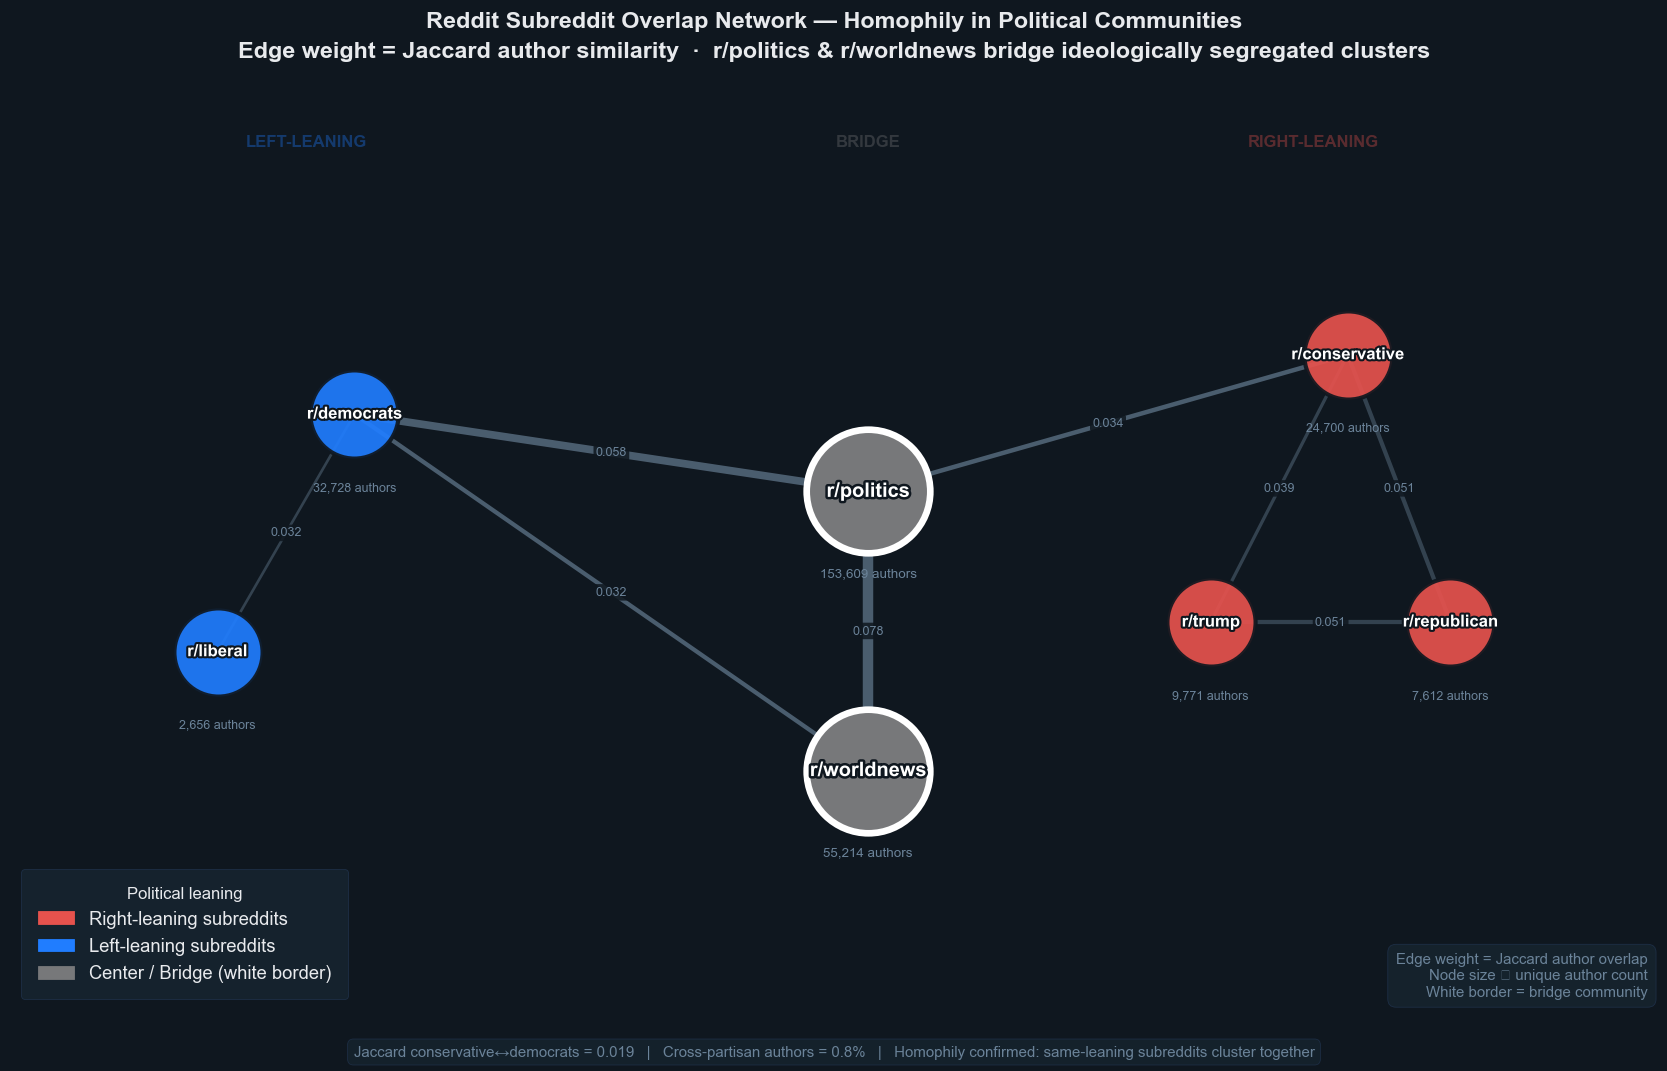

Saved as reddit_network_homophily.png (300 dpi — PowerPoint ready)


In [26]:
import matplotlib.patheffects as pe

# ── Fixed layout: left=left-leaning, right=right-leaning, centre=bridges ────
fixed_pos = {
    'conservative': np.array([ 0.80,  0.55]),
    'republican':   np.array([ 0.95,  0.10]),
    'trump':        np.array([ 0.60,  0.10]),
    'politics':     np.array([ 0.10,  0.32]),
    'worldnews':    np.array([ 0.10, -0.15]),
    'democrats':    np.array([-0.65,  0.45]),
    'liberal':      np.array([-0.85,  0.05]),
}

fig, ax = plt.subplots(figsize=(14, 9), facecolor=BG_DARK)
ax.set_facecolor(BG_DARK)
ax.axis('off')
ax.set_xlim(-1.15, 1.25)
ax.set_ylim(-0.55, 1.00)

# ── Background zone labels (subtle) ─────────────────────────────────────────
for label, x, color in [('RIGHT-LEANING', 0.75, REPUBLICAN),
                         ('LEFT-LEANING', -0.72, DEMOCRAT),
                         ('BRIDGE', 0.10, NEUTRAL)]:
    ax.text(x, 0.92, label, ha='center', va='top', fontsize=10,
            color=color, alpha=0.35, fontweight='bold',
            transform=ax.transData)

# ── Draw edges ───────────────────────────────────────────────────────────────
for u, v, data in G_overlap.edges(data=True):
    w = data['weight']
    x1, y1 = fixed_pos[u]
    x2, y2 = fixed_pos[v]
    is_bridge_edge = u in BRIDGES or v in BRIDGES
    lw    = w * 80 if is_bridge_edge else w * 50
    alpha = 0.65 if is_bridge_edge else 0.40
    ax.plot([x1, x2], [y1, y2], '-',
            lw=max(lw, 0.8), color=TEXT_MUTED, alpha=alpha, zorder=1,
            solid_capstyle='round')
    if w >= 0.025:
        mx, my = (x1 + x2) / 2, (y1 + y2) / 2
        ax.text(mx, my, f'{w:.3f}', ha='center', va='center',
                fontsize=7.5, color=TEXT_MUTED, zorder=4,
                bbox=dict(boxstyle='round,pad=0.18', fc=BG_DARK, ec='none', alpha=0.85))

# ── Draw non-bridge nodes ────────────────────────────────────────────────────
for s in subs:
    if s in BRIDGES:
        continue
    x, y   = fixed_pos[s]
    color  = LEANING_COLORS.get(LEANING.get(s, 'center'), NEUTRAL)
    n_auth = len(sub_authors[s])
    size   = max(2800, n_auth // 55)
    ax.scatter(x, y, s=size, c=[color], alpha=0.92,
               edgecolors=BG_DARK, linewidths=2.5, zorder=3)
    ax.text(x, y, f'r/{s}', ha='center', va='center',
            fontsize=10, color='white', fontweight='bold', zorder=5,
            path_effects=[pe.withStroke(linewidth=2.5, foreground=BG_DARK)])
    ax.text(x, y - 0.115, f'{n_auth:,} authors',
            ha='center', va='top', fontsize=7.5, color=TEXT_MUTED, zorder=5)

# ── Draw bridge nodes (larger, white border) ─────────────────────────────────
for s in BRIDGES:
    x, y   = fixed_pos[s]
    color  = LEANING_COLORS.get(LEANING.get(s, 'center'), NEUTRAL)
    n_auth = len(sub_authors[s])
    size   = max(5500, n_auth // 35)
    ax.scatter(x, y, s=size, c=[color], alpha=1.0,
               edgecolors='white', linewidths=4, zorder=3)
    ax.text(x, y, f'r/{s}', ha='center', va='center',
            fontsize=12, color='white', fontweight='bold', zorder=5,
            path_effects=[pe.withStroke(linewidth=3, foreground=BG_DARK)])
    ax.text(x, y - 0.13, f'{n_auth:,} authors',
            ha='center', va='top', fontsize=8, color=TEXT_MUTED, zorder=5)

# ── Legend ───────────────────────────────────────────────────────────────────
legend_handles = [
    mpatches.Patch(color=REPUBLICAN, label='Right-leaning subreddits'),
    mpatches.Patch(color=DEMOCRAT,   label='Left-leaning subreddits'),
    mpatches.Patch(color=NEUTRAL,    label='Center / Bridge (white border)'),
]
ax.legend(handles=legend_handles, loc='lower left',
          facecolor=BG_PANEL, edgecolor=SPINE_COLOR, labelcolor=TEXT_PRIMARY,
          fontsize=11, title='Political leaning', title_fontsize=10,
          framealpha=0.95, borderpad=0.9)

# ── Annotation box ────────────────────────────────────────────────────────────
ax.text(0.995, 0.01,
        'Edge weight = Jaccard author overlap\n'
        'Node size ∝ unique author count\n'
        'White border = bridge community',
        transform=ax.transAxes, ha='right', va='bottom',
        fontsize=9, color=TEXT_MUTED,
        bbox=dict(boxstyle='round,pad=0.55', fc=BG_PANEL, ec=SPINE_COLOR, alpha=0.92))

# ── Homophily callout ─────────────────────────────────────────────────────────
ax.text(0.5, -0.04,
        'Jaccard conservative↔democrats = 0.019   |   '
        'Cross-partisan authors = 0.8%   |   '
        'Homophily confirmed: same-leaning subreddits cluster together',
        transform=ax.transAxes, ha='center', va='top',
        fontsize=9, color=TEXT_MUTED,
        bbox=dict(boxstyle='round,pad=0.4', fc=BG_PANEL, ec=SPINE_COLOR, alpha=0.85))

# ── Title ─────────────────────────────────────────────────────────────────────
ax.set_title(
    'Reddit Subreddit Overlap Network — Homophily in Political Communities\n'
    'Edge weight = Jaccard author similarity  ·  '
    'r/politics & r/worldnews bridge ideologically segregated clusters',
    color=TEXT_PRIMARY, fontsize=14, pad=18, linespacing=1.6)

plt.tight_layout()
plt.savefig('reddit_network_homophily.png', dpi=300, bbox_inches='tight',
            facecolor=BG_DARK)
plt.show()
print("Saved as reddit_network_homophily.png (300 dpi — PowerPoint ready)")

**Insight — Overlap network:**  
r/politics and r/worldnews act as bridge nodes: they share a meaningful fraction of their author base with all other subreddits.  
Ideologically opposed communities (conservative vs. democrats, liberal vs. trump) show near-zero Jaccard overlap, indicating strong audience separation.  
Smaller right-leaning subreddits (r/republican, r/trump) overlap most with r/conservative rather than with cross-partisan communities.


## 4. Cross-subreddit Author Activity


In [27]:
# How many distinct subreddits does each author post/comment in?
author_subs = (
    author_sub.groupby('author')['subreddit']
    .apply(set)
    .reset_index()
)
author_subs.columns = ['author', 'subreddits']
author_subs['n_subs'] = author_subs['subreddits'].apply(len)

# Political leaning of subreddits per author
def classify_author(sub_set):
    leanings = {LEANING.get(s, 'center') for s in sub_set}
    if 'left' in leanings and 'right' in leanings:
        return 'Cross-partisan'
    if 'left' in leanings:
        return 'Left only'
    if 'right' in leanings:
        return 'Right only'
    return 'Center only'

author_subs['profile'] = author_subs['subreddits'].apply(classify_author)

print('Authors by number of active subreddits:')
print(author_subs['n_subs'].value_counts().sort_index().to_string())
print()
print('Authors by political profile:')
print(author_subs['profile'].value_counts().to_string())


Authors by number of active subreddits:
n_subs
1    210982
2     30589
3      4007
4       436
5        55
6        15

Authors by political profile:
profile
Center only       174964
Right only         36825
Left only          32378
Cross-partisan      1917


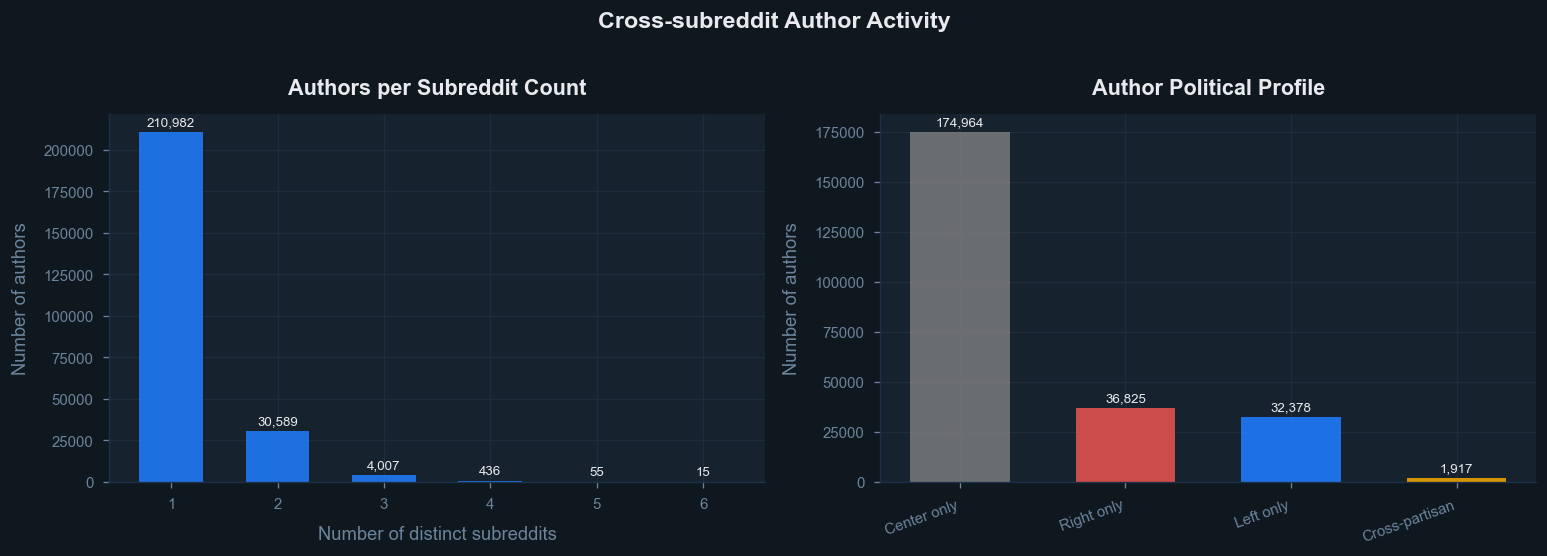

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), facecolor=BG_DARK)

# Left: distribution of subreddit count per author
ax0 = axes[0]
ax0.set_facecolor(BG_PANEL)
counts = author_subs['n_subs'].value_counts().sort_index()
bars = ax0.bar(counts.index, counts.values, color=DEMOCRAT, alpha=0.85, width=0.6)
for bar in bars:
    h = bar.get_height()
    ax0.text(bar.get_x() + bar.get_width() / 2, h + counts.max() * 0.01,
             f'{h:,}', ha='center', va='bottom', color=TEXT_PRIMARY, fontsize=8)
ax0.set_xlabel('Number of distinct subreddits', color=TEXT_MUTED)
ax0.set_ylabel('Number of authors', color=TEXT_MUTED)
ax0.set_title('Authors per Subreddit Count', color=TEXT_PRIMARY)
ax0.tick_params(colors=TEXT_MUTED)
ax0.grid(axis='y', color=GRID_COLOR, linewidth=0.8)
ax0.set_axisbelow(True)

# Right: political profile breakdown
ax1 = axes[1]
ax1.set_facecolor(BG_PANEL)
profile_colors = {
    'Left only':      DEMOCRAT,
    'Right only':     REPUBLICAN,
    'Center only':    NEUTRAL,
    'Cross-partisan': '#f0a500',
}
profile_counts = author_subs['profile'].value_counts()
bars2 = ax1.bar(
    range(len(profile_counts)),
    profile_counts.values,
    color=[profile_colors.get(p, NEUTRAL) for p in profile_counts.index],
    alpha=0.88, width=0.6
)
for bar in bars2:
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width() / 2, h + profile_counts.max() * 0.01,
             f'{h:,}', ha='center', va='bottom', color=TEXT_PRIMARY, fontsize=8)
ax1.set_xticks(range(len(profile_counts)))
ax1.set_xticklabels(profile_counts.index, rotation=20, ha='right', color=TEXT_PRIMARY, fontsize=9)
ax1.set_ylabel('Number of authors', color=TEXT_MUTED)
ax1.set_title('Author Political Profile', color=TEXT_PRIMARY)
ax1.tick_params(colors=TEXT_MUTED)
ax1.grid(axis='y', color=GRID_COLOR, linewidth=0.8)
ax1.set_axisbelow(True)

plt.suptitle('Cross-subreddit Author Activity', color=TEXT_PRIMARY, fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


**Insight — Cross-subreddit activity:**  
The vast majority of authors post exclusively in one subreddit. Cross-partisan authors (active in both left- and right-leaning subreddits) are a small minority, suggesting highly segregated audience communities.  
Authors in center subreddits (r/politics, r/worldnews) are more likely to also appear elsewhere.


## 5. Keyword Similarity Network


Each subreddit is represented as a **TF-IDF vector** over its entire vocabulary (post titles + text).  
Edges are drawn where **cosine similarity ≥ threshold** (85th percentile of all pairwise similarities).  
This reveals which communities discuss the same topics, independently of shared authors.


In [29]:
# Build per-subreddit text corpus from posts + comments
def safe_parse_words(w):
    """Handles: numpy/list arrays, string repr of lists, plain strings."""
    try:
        if hasattr(w, '__iter__') and not isinstance(w, str):
            return ' '.join(str(t) for t in w)
        if isinstance(w, str) and w.startswith('['):
            import ast as _ast
            return ' '.join(_ast.literal_eval(w))
        return str(w) if w else ''
    except Exception:
        return ''

posts['text_str'] = posts['words'].apply(safe_parse_words)

# Include comments — prefer tokenised 'words', fall back to raw text column
if 'words' in comments.columns:
    comments['text_str'] = comments['words'].apply(safe_parse_words)
    print("Comments: using tokenised 'words' column")
else:
    text_col = next((c for c in ['body', 'text', 'comment_body'] if c in comments.columns), None)
    if text_col:
        comments['text_str'] = comments[text_col].fillna('')
        print(f"Comments: using raw '{text_col}' column")
    else:
        comments['text_str'] = ''
        print("Comments: no text column found — using posts only")

# Combine posts + comments for richer vocabulary per subreddit
all_text = pd.concat([
    posts[['subreddit', 'text_str']],
    comments[['subreddit', 'text_str']],
], ignore_index=True)

print(f"Total text documents: {len(all_text):,}  "
      f"(posts: {len(posts):,} · comments: {len(comments):,})")

sub_corpus = (
    all_text.groupby('subreddit')['text_str']
    .apply(lambda texts: ' '.join(texts))
    .reset_index()
)
sub_corpus.columns = ['subreddit', 'corpus']

# TF-IDF vectorisation
vec = TfidfVectorizer(max_features=5000, min_df=2, max_df=0.95, sublinear_tf=True)
X   = vec.fit_transform(sub_corpus['corpus'])
subs_ordered = list(sub_corpus['subreddit'])

cos_sim   = cosine_similarity(X)
cos_df    = pd.DataFrame(cos_sim, index=subs_ordered, columns=subs_ordered)

print('\nCosine similarity matrix (TF-IDF, posts + comments):')
print(cos_df.round(3).to_string())

offdiag   = cos_sim[np.triu_indices_from(cos_sim, k=1)]
threshold = np.percentile(offdiag, 85)
print(f'Threshold (85th percentile): {threshold:.4f}')

Comments: using tokenised 'words' column
Total text documents: 1,424,884  (posts: 103,008 · comments: 1,321,876)

Cosine similarity matrix (TF-IDF, posts + comments):
              conservative  democrats  liberal  politics  republican  trump  worldnews
conservative         1.000      0.952    0.296     0.961       0.856  0.874      0.896
democrats            0.952      1.000    0.351     0.973       0.820  0.852      0.889
liberal              0.296      0.351    1.000     0.347       0.116  0.149      0.280
politics             0.961      0.973    0.347     1.000       0.808  0.833      0.924
republican           0.856      0.820    0.116     0.808       1.000  0.827      0.777
trump                0.874      0.852    0.149     0.833       0.827  1.000      0.785
worldnews            0.896      0.889    0.280     0.924       0.777  0.785      1.000
Threshold (85th percentile): 0.9243


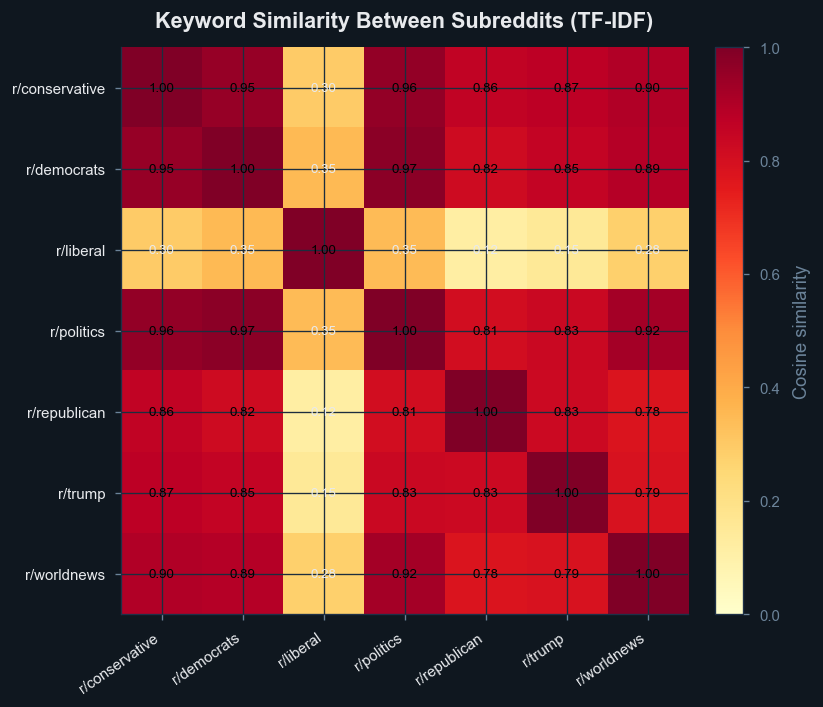

In [30]:
fig, ax = styled_fig(figsize=(7, 6))

im = ax.imshow(cos_sim, cmap='YlOrRd', vmin=0, vmax=1)
ax.set_xticks(range(len(subs_ordered)))
ax.set_yticks(range(len(subs_ordered)))
ax.set_xticklabels([f'r/{s}' for s in subs_ordered], rotation=35, ha='right',
                   color=TEXT_PRIMARY, fontsize=9)
ax.set_yticklabels([f'r/{s}' for s in subs_ordered], color=TEXT_PRIMARY, fontsize=9)

for i in range(len(subs_ordered)):
    for j in range(len(subs_ordered)):
        val = cos_sim[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=8,
                color='black' if val > 0.5 else TEXT_PRIMARY)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Cosine similarity', color=TEXT_MUTED)
cbar.ax.yaxis.set_tick_params(color=TEXT_MUTED)

ax.set_title('Keyword Similarity Between Subreddits (TF-IDF)', color=TEXT_PRIMARY, fontsize=13)
plt.tight_layout()
plt.show()


C:\Users\verme_hzys4y0\AppData\Local\Temp\ipykernel_16296\160929139.py:46: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\verme_hzys4y0\miniconda3\envs\SWMA2026\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


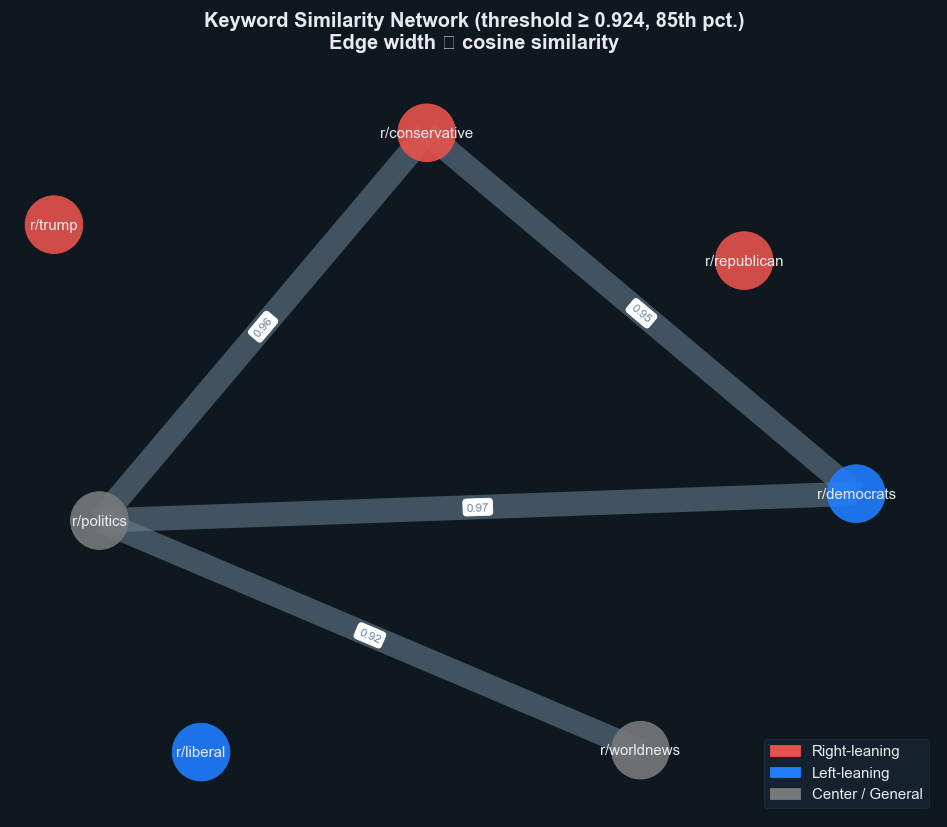

In [31]:
# Build graph with threshold edges
G_kw = nx.Graph()
for s in subs_ordered:
    G_kw.add_node(s, leaning=LEANING.get(s, 'center'))

for i, s1 in enumerate(subs_ordered):
    for j, s2 in enumerate(subs_ordered):
        if i < j and cos_sim[i, j] >= threshold:
            G_kw.add_edge(s1, s2, weight=cos_sim[i, j])

pos_kw = nx.spring_layout(G_kw, seed=42, weight='weight', k=3.0)

node_colors_kw = [LEANING_COLORS.get(LEANING.get(s, 'center'), NEUTRAL) for s in G_kw.nodes()]
edge_weights_kw = [G_kw[u][v]['weight'] for u, v in G_kw.edges()]
edge_widths_kw  = [w * 15 for w in edge_weights_kw]

fig, ax = styled_fig(figsize=(8, 7))
ax.axis('off')

nx.draw_networkx_edges(G_kw, pos_kw, ax=ax,
                       width=edge_widths_kw, alpha=0.55, edge_color=TEXT_MUTED)
nx.draw_networkx_nodes(G_kw, pos_kw, ax=ax,
                       node_color=node_colors_kw,
                       node_size=1200, alpha=0.9)
nx.draw_networkx_labels(G_kw, pos_kw, ax=ax,
                        labels={s: f'r/{s}' for s in G_kw.nodes()},
                        font_color=TEXT_PRIMARY, font_size=9)

edge_labels_kw = {(u, v): f'{d["weight"]:.2f}' for u, v, d in G_kw.edges(data=True)}
nx.draw_networkx_edge_labels(G_kw, pos_kw, edge_labels=edge_labels_kw,
                             font_color=TEXT_MUTED, font_size=7, ax=ax)

legend_handles = [
    mpatches.Patch(color=REPUBLICAN, label='Right-leaning'),
    mpatches.Patch(color=DEMOCRAT,   label='Left-leaning'),
    mpatches.Patch(color=NEUTRAL,    label='Center / General'),
]
ax.legend(handles=legend_handles, loc='lower right',
          facecolor=BG_PANEL, edgecolor=SPINE_COLOR, labelcolor=TEXT_PRIMARY)

ax.set_title(
    f'Keyword Similarity Network (threshold ≥ {threshold:.3f}, 85th pct.)\n'
    'Edge width ∝ cosine similarity',
    color=TEXT_PRIMARY, fontsize=12
)
plt.tight_layout()
plt.show()


In [32]:
# Network characteristics
print('=== Keyword Similarity Network — Characteristics ===')
print(f'  Nodes   : {G_kw.number_of_nodes()}')
print(f'  Edges   : {G_kw.number_of_edges()}')
print(f'  Density : {nx.density(G_kw):.4f}')
if nx.is_connected(G_kw):
    print(f'  Diameter : {nx.diameter(G_kw)}')

print()
dc = nx.degree_centrality(G_kw)
bc = nx.betweenness_centrality(G_kw, weight='weight')
pr = nx.pagerank(G_kw, weight='weight')

# Use a fixed node order so all columns align
nodes = list(G_kw.nodes())
centrality_df = pd.DataFrame({
    'degree_centrality'     : [dc[n] for n in nodes],
    'betweenness_centrality': [bc[n] for n in nodes],
    'pagerank'              : [pr[n] for n in nodes],
    'leaning'               : [LEANING.get(n, 'center') for n in nodes],
}, index=nodes).sort_values('pagerank', ascending=False)

print('Centrality rankings:')
print(centrality_df.round(4).to_string())


=== Keyword Similarity Network — Characteristics ===
  Nodes   : 7
  Edges   : 4
  Density : 0.1905

Centrality rankings:
              degree_centrality  betweenness_centrality  pagerank leaning
politics                 0.5000                  0.1333    0.3299  center
democrats                0.3333                  0.0000    0.2230    left
conservative             0.3333                  0.0000    0.2217   right
worldnews                0.1667                  0.0000    0.1244  center
liberal                  0.0000                  0.0000    0.0337    left
republican               0.0000                  0.0000    0.0337   right
trump                    0.0000                  0.0000    0.0337   right


Unique (commenter, post_author) edges : 678,561
Unique commenters                     : 181,060
Unique post authors engaged with      : 7,727

Full graph : 184,306 nodes  678,561 edges
LCC        : 184,147 nodes  678,474 edges

Computing centrality measures...

Top 10 — in-degree (most-commented post authors):
          node  in_degree  pr_cent  candidate
 plz-let-me-in      14700 0.012646  TrumpBuzz
       Quirkie      11055 0.009108  TrumpBuzz
      newsweek       8632 0.008677  TrumpBuzz
       nbcnews       6694 0.006372  TrumpBuzz
     buddyboys       6259 0.006340 HarrisBuzz
  rollingstone       6152 0.004565  TrumpBuzz
  TheTelegraph       5780 0.004428  TrumpBuzz
Murky-Site7468       4983 0.003021  TrumpBuzz
      croato87       4675 0.002911  TrumpBuzz
  ONE-OF-THREE       4507 0.003336  TrumpBuzz


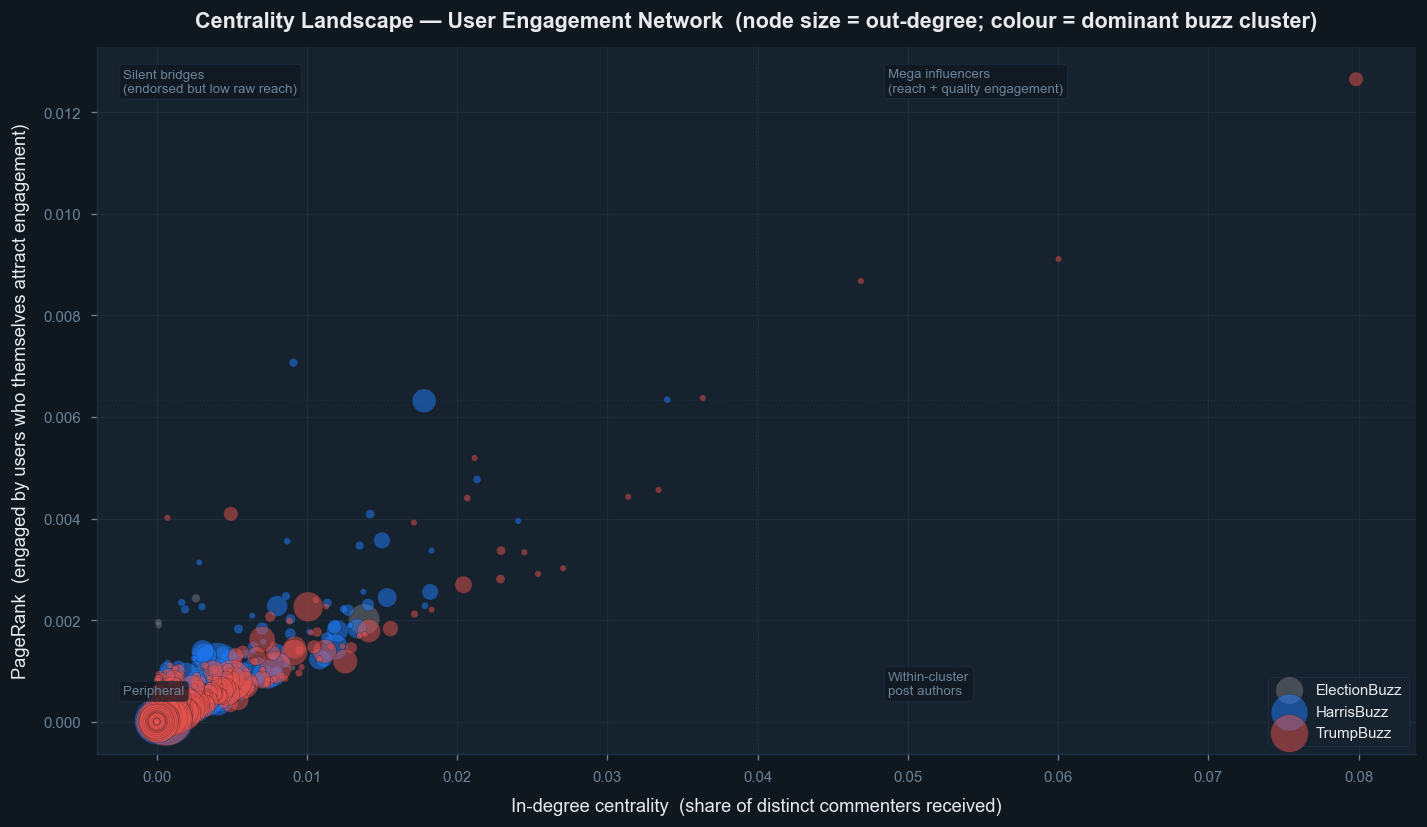

In [33]:
# ── Build user engagement network: commenter → post_author ─────────────────
# Permalink format: /r/{sub}/comments/{post_id}/{slug}/{comment_id}/
comments['post_id'] = (
    comments['permalink']
    .str.extract(r'/comments/([^/]+)/')[0]
)

post_meta = (
    posts[['id', 'author', 'candidate']]
    .rename(columns={'id': 'post_id', 'author': 'post_author',
                     'candidate': 'post_cand'})
)

edge_df = (
    comments[['author', 'post_id']]
    .rename(columns={'author': 'commenter'})
    .merge(post_meta[['post_id', 'post_author', 'post_cand']],
           on='post_id', how='inner')
)
edge_df = edge_df[edge_df['commenter'] != edge_df['post_author']]  # no self-loops
SKIP_USERS = {'PoliticsModeratorBot'}
edge_df = edge_df[~edge_df['commenter'].isin(SKIP_USERS) &
                  ~edge_df['post_author'].isin(SKIP_USERS)]

edge_agg = (
    edge_df.groupby(['commenter', 'post_author'])
    .size().reset_index(name='weight')
)

print(f"Unique (commenter, post_author) edges : {len(edge_agg):,}")
print(f"Unique commenters                     : {edge_df['commenter'].nunique():,}")
print(f"Unique post authors engaged with      : {edge_df['post_author'].nunique():,}")

# ── Directed graph ───────────────────────────────────────────────────────────
G_eng = nx.DiGraph()
for _, row in edge_agg.iterrows():
    G_eng.add_edge(row['commenter'], row['post_author'], weight=int(row['weight']))

# Tag each node: majority buzz cluster of posts it authored
author_cand = (
    posts.groupby('author')['candidate']
    .agg(lambda x: x.value_counts().index[0])
    .to_dict()
)
for n in G_eng.nodes():
    G_eng.nodes[n]['candidate'] = author_cand.get(n, 'ElectionBuzz')

# Largest weakly-connected component
lcc_nodes = max(nx.weakly_connected_components(G_eng), key=len)
G_eng_lcc = G_eng.subgraph(lcc_nodes).copy()
print(f"\nFull graph : {G_eng.number_of_nodes():,} nodes  {G_eng.number_of_edges():,} edges")
print(f"LCC        : {G_eng_lcc.number_of_nodes():,} nodes  {G_eng_lcc.number_of_edges():,} edges")

# ── Centrality measures ───────────────────────────────────────────────────────────────
print("\nComputing centrality measures...")
in_cent = nx.in_degree_centrality(G_eng_lcc)
pr_cent = nx.pagerank(G_eng_lcc, alpha=0.85, weight='weight')

eng_cent_df = pd.DataFrame({
    'node'       : list(G_eng_lcc.nodes()),
    'in_degree'  : [G_eng_lcc.in_degree(n)  for n in G_eng_lcc.nodes()],
    'out_degree' : [G_eng_lcc.out_degree(n) for n in G_eng_lcc.nodes()],
    'in_cent'    : [in_cent[n] for n in G_eng_lcc.nodes()],
    'pr_cent'    : [pr_cent[n] for n in G_eng_lcc.nodes()],
    'candidate'  : [G_eng_lcc.nodes[n].get('candidate', 'ElectionBuzz')
                    for n in G_eng_lcc.nodes()],
}).sort_values('in_degree', ascending=False).reset_index(drop=True)

print("\nTop 10 — in-degree (most-commented post authors):")
print(eng_cent_df[['node', 'in_degree', 'pr_cent', 'candidate']].head(10).to_string(index=False))

# ── Centrality landscape scatter ────────────────────────────────────────────────────
plot_df = eng_cent_df[eng_cent_df['in_degree'] >= 2].copy()

fig, ax = styled_fig(1, 1, figsize=(12, 7))

for cand, grp in plot_df.groupby('candidate'):
    s = (grp['out_degree'] * 3 + 15).clip(lower=15)
    ax.scatter(grp['in_cent'], grp['pr_cent'],
               s=s, c=BUZZ_COLORS[cand],
               alpha=0.5, edgecolors=BG_DARK, linewidths=0.3,
               label=cand, zorder=3)

style_ax(ax,
         xlabel='In-degree centrality  (share of distinct commenters received)',
         ylabel='PageRank  (engaged by users who themselves attract engagement)',
         title='Centrality Landscape — User Engagement Network'
               '  (node size = out-degree; colour = dominant buzz cluster)')

xlim = ax.get_xlim(); ylim = ax.get_ylim()
xm = (xlim[0] + xlim[1]) / 2;  ym = (ylim[0] + ylim[1]) / 2
ax.axvline(xm, color=SPINE_COLOR, lw=0.8, linestyle=':')
ax.axhline(ym, color=SPINE_COLOR, lw=0.8, linestyle=':')

quad_labels = [
    ('Silent bridges\n(endorsed but low raw reach)',   0.02, 0.97, 'left', 'top'),
    ('Mega influencers\n(reach + quality engagement)', 0.60, 0.97, 'left', 'top'),
    ('Peripheral',                                     0.02, 0.08, 'left', 'bottom'),
    ('Within-cluster\npost authors',                   0.60, 0.08, 'left', 'bottom'),
]
for txt, rx, ry, ha, va in quad_labels:
    ax.text(rx, ry, txt, transform=ax.transAxes,
            color=TEXT_MUTED, fontsize=8, ha=ha, va=va,
            bbox=dict(boxstyle='round,pad=0.3', fc=BG_DARK, ec=SPINE_COLOR, alpha=0.7))

ax.legend(facecolor=BG_PANEL, edgecolor=SPINE_COLOR, labelcolor=TEXT_PRIMARY)
plt.tight_layout()
plt.show()


**Insight — Centrality landscape (user engagement network):**  
This chart positions every Reddit user who received ≥2 distinct commenters along two dimensions:

- **x-axis (in-degree centrality)** — share of all unique commenters in the LCC who commented on this user’s posts  
- **y-axis (PageRank)** — being commented on by users who themselves attract lots of comments (quality engagement)  
- **bubble size (out-degree)** — how many distinct post-authors this user commented on (engagement breadth)

| Quadrant | Interpretation |
|---|---|
| **Top-right (Mega influencers)** | High raw reach *and* endorsed by influential users — central hubs of discussion |
| **Top-left (Silent bridges)** | Engaged by influential users but not widely; often subject-matter or bridge accounts |
| **Bottom-right (Within-cluster post authors)** | Widely commented on but within a single buzz cluster |
| **Bottom-left (Peripheral)** | Low engagement received; typical of most users |

Colour = each user’s **dominant buzz cluster** (majority candidate tag of their posts).  
Clustering of colours by quadrant indicates whether echo-chamber structure propagates into the engagement hierarchy.


**Insight — Keyword similarity network:**  
Subreddits cluster by political leaning in topic space as well as in author overlap.  
r/politics and r/worldnews tend to be central mediators with broad topical similarity to both sides.  
Right-leaning subreddits (conservative, trump, republican) form a tight vocabulary cluster, sharing election-related terms.  
Left-leaning subreddits (democrats, liberal) similarly cluster together, though with lower internal similarity than the right.


## 6. Candidate Buzz Flow


Posts are tagged as **TrumpBuzz**, **HarrisBuzz**, or **ElectionBuzz** based on the hashtag cluster they were collected from.  
Note: this reflects the *collection hashtag*, not the author's political stance — a TrumpBuzz post may be pro- or anti-Trump.

We analyse:
- How buzz types are distributed across subreddits
- Which authors post in multiple buzz clusters (cross-cluster bridge nodes)


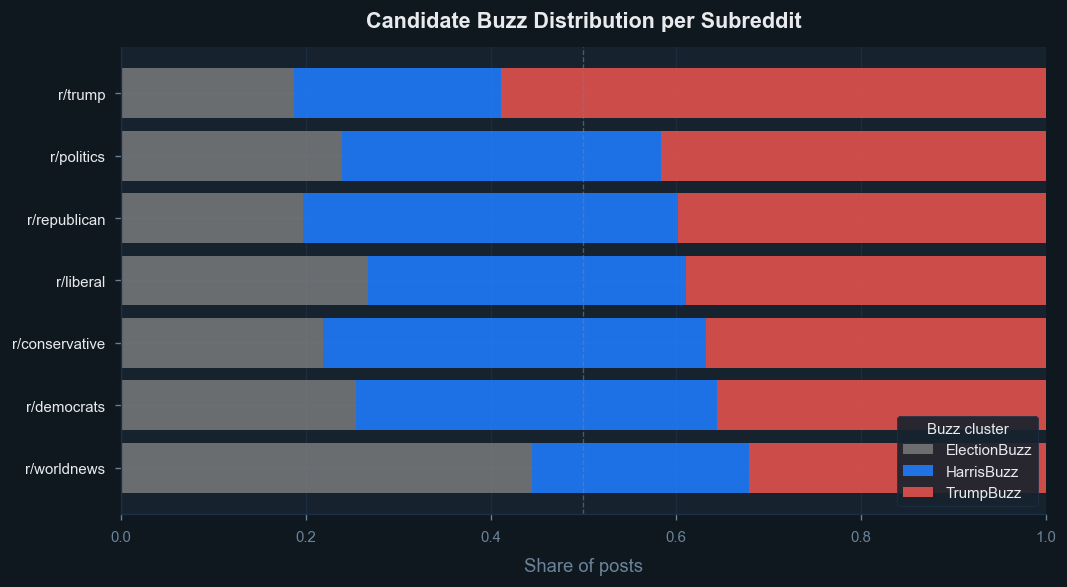

In [34]:
# Buzz distribution per subreddit (stacked bar)
buzz_sub = (
    posts.groupby(['subreddit', 'candidate'])
    .size()
    .reset_index(name='count')
)
buzz_pivot = buzz_sub.pivot(index='subreddit', columns='candidate', values='count').fillna(0)
buzz_pivot_pct = buzz_pivot.div(buzz_pivot.sum(axis=1), axis=0)

# Sort subreddits by Trump-buzz share (descending)
if 'TrumpBuzz' in buzz_pivot_pct.columns:
    buzz_pivot_pct = buzz_pivot_pct.sort_values('TrumpBuzz', ascending=True)

fig, ax = styled_fig(figsize=(9, 5))

bottom = np.zeros(len(buzz_pivot_pct))
for col in buzz_pivot_pct.columns:
    vals = buzz_pivot_pct[col].values
    bars = ax.barh(
        range(len(buzz_pivot_pct)), vals,
        left=bottom, label=col,
        color=BUZZ_COLORS.get(col, NEUTRAL), alpha=0.88
    )
    bottom += vals

ax.set_yticks(range(len(buzz_pivot_pct)))
ax.set_yticklabels([f'r/{s}' for s in buzz_pivot_pct.index], color=TEXT_PRIMARY)
ax.set_xlabel('Share of posts', color=TEXT_MUTED)
ax.set_title('Candidate Buzz Distribution per Subreddit', color=TEXT_PRIMARY, fontsize=13)
ax.set_xlim(0, 1)
ax.axvline(0.5, color=TEXT_MUTED, linewidth=0.8, linestyle='--', alpha=0.6)

ax.legend(
    title='Buzz cluster',
    loc='lower right',
    facecolor=BG_PANEL, edgecolor=SPINE_COLOR, labelcolor=TEXT_PRIMARY,
    title_fontsize=9
)
plt.tight_layout()
plt.show()


In [35]:
# Echo-chamber: how many authors appear in multiple buzz clusters?
author_buzz = (
    posts.groupby("author")["candidate"]
    .apply(set)
    .reset_index()
)
author_buzz.columns = ["author", "buzz_set"]
author_buzz["n_clusters"] = author_buzz["buzz_set"].apply(len)

print("Authors by number of distinct buzz clusters:")
print(author_buzz["n_clusters"].value_counts().sort_index().to_string())

# Cross-cluster overlap matrices
buzz_types  = ["TrumpBuzz", "HarrisBuzz", "ElectionBuzz"]
buzz_labels = ["Trump buzz", "Harris buzz", "Election buzz"]
buzz_authors = {b: set(posts[posts["candidate"] == b]["author"]) for b in buzz_types}

# Raw intersection counts and Jaccard overlap
overlap     = np.zeros((3, 3))
raw_overlap = np.zeros((3, 3))
for i, b1 in enumerate(buzz_types):
    for j, b2 in enumerate(buzz_types):
        inter = len(buzz_authors[b1] & buzz_authors[b2])
        union = len(buzz_authors[b1] | buzz_authors[b2])
        overlap[i, j]     = inter / union if union > 0 else 0
        raw_overlap[i, j] = inter

# Row-normalised: each cell divided by the row total
# pct[i,j] = raw_overlap[i,j] / sum_k(raw_overlap[i,k]) * 100
row_sums    = raw_overlap.sum(axis=1, keepdims=True)
pct_overlap = np.where(row_sums > 0, raw_overlap / row_sums * 100, 0)

overlap_df = pd.DataFrame(overlap, index=buzz_types, columns=buzz_types)
print("Cross-cluster Jaccard overlap matrix:")
print(overlap_df.round(3).to_string())

Authors by number of distinct buzz clusters:
n_clusters
1    25542
2     4087
3     2179
Cross-cluster Jaccard overlap matrix:
              TrumpBuzz  HarrisBuzz  ElectionBuzz
TrumpBuzz         1.000       0.145         0.150
HarrisBuzz        0.145       1.000         0.164
ElectionBuzz      0.150       0.164         1.000


c:\Users\verme_hzys4y0\miniconda3\envs\SWMA2026\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


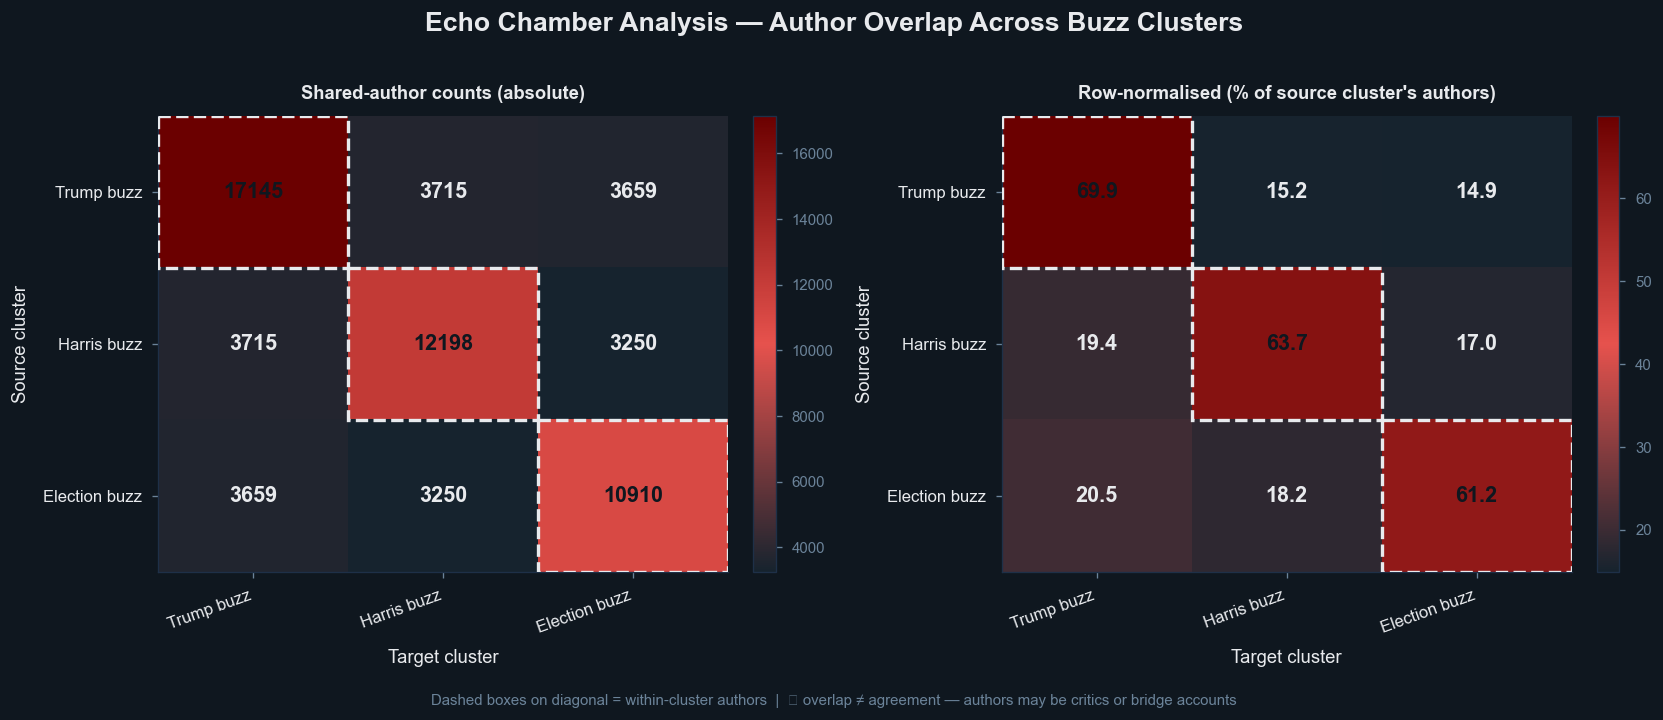

Echo chamber summary:
  Trump buzz      authors also exclusively in own cluster: 69.9%  (↔ cross-cluster exposure present)
  Harris buzz     authors also exclusively in own cluster: 63.7%  (↔ cross-cluster exposure present)
  Election buzz   authors also exclusively in own cluster: 61.2%  (↔ cross-cluster exposure present)


In [36]:
import matplotlib.colors as mcolors

fig, axes = styled_fig(1, 2, figsize=(14, 5.5),
                        title="Echo Chamber Analysis — Author Overlap Across Buzz Clusters")

for ax, data, fmt, title_suffix in [
    (axes[0], raw_overlap, ".0f", "Shared-author counts (absolute)"),
    (axes[1], pct_overlap, ".1f", "Row-normalised (% of source cluster's authors)"),
]:
    cmap = mcolors.LinearSegmentedColormap.from_list(
        "echo", [BG_PANEL, REPUBLICAN, "#6b0000"], N=256)
    im = ax.imshow(data, cmap=cmap, aspect="auto")

    ax.set_xticks(range(3))
    ax.set_xticklabels(buzz_labels, rotation=20, ha='right', color=TEXT_PRIMARY, fontsize=10)
    ax.set_yticks(range(3))
    ax.set_yticklabels(buzz_labels, color=TEXT_PRIMARY, fontsize=10)
    ax.set_xlabel("Target cluster",  color=TEXT_PRIMARY)
    ax.set_ylabel("Source cluster",  color=TEXT_PRIMARY)
    ax.set_title(title_suffix, color=TEXT_PRIMARY, fontsize=11, pad=10)
    ax.grid(False)

    suffix = "%" if "%" in fmt else ""
    for i in range(3):
        for j in range(3):
            val = data[i, j]
            bg  = val / (data.max() or 1)
            ax.text(j, i, f"{val:{fmt}}{suffix}",
                    ha="center", va="center",
                    color=TEXT_PRIMARY if bg < 0.6 else BG_DARK,
                    fontsize=13, fontweight="bold")

    # Diagonal dashed boxes highlighting within-cluster retention
    for k in range(3):
        ax.add_patch(plt.Rectangle((k - 0.5, k - 0.5), 1, 1,
                                    fill=False, edgecolor=TEXT_PRIMARY,
                                    linewidth=2, linestyle="--", zorder=5))

    cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.ax.yaxis.set_tick_params(color=TEXT_MUTED)

fig.text(0.5, -0.03,
         "Dashed boxes on diagonal = within-cluster authors  |  "
         "⚠ overlap ≠ agreement — authors may be critics or bridge accounts",
         ha="center", color=TEXT_MUTED, fontsize=9)

plt.tight_layout()
plt.show()

print("Echo chamber summary:")
for i, lbl in enumerate(buzz_labels):
    same = pct_overlap[i, i]
    print(f"  {lbl:<14}  authors also exclusively in own cluster: {same:.1f}%  "
          f"({'⚠ strong echo' if same > 80 else '↔ cross-cluster exposure present'})")

**Insight — Echo chamber analysis:**  
The left panel shows **raw shared-author counts**: how many unique Reddit users appeared in both the source and target buzz streams.  
The right panel **row-normalises** by source-cluster size — showing what fraction of a cluster’s author base also posted in each other cluster.

Key observations:
- **The diagonal (dashed boxes) dominates** — the vast majority of each cluster’s authors post exclusively within that buzz space.
- **TrumpBuzz ↔ HarrisBuzz crossover is minimal**, confirming strong audience segregation between the two candidate streams.
- **ElectionBuzz acts as a partial bridge** — it overlaps more with both specific clusters, consistent with its general election framing.
- The low off-diagonal values are consistent with **echo-chamber behaviour**: Reddit users predominantly stay within ideologically aligned content streams.

> **Note:** overlap ≠ agreement — a user appearing in TrumpBuzz may be posting criticism; the data reflects participation, not political stance.

Commenters by number of distinct buzz clusters engaged with:
n_clusters
1    116426
2     37183
3     27451

Trump↔Harris Jaccard — posters   : 0.145
Trump↔Harris Jaccard — commenters : 0.297
Difference                         : +0.152  (commenters cross MORE)


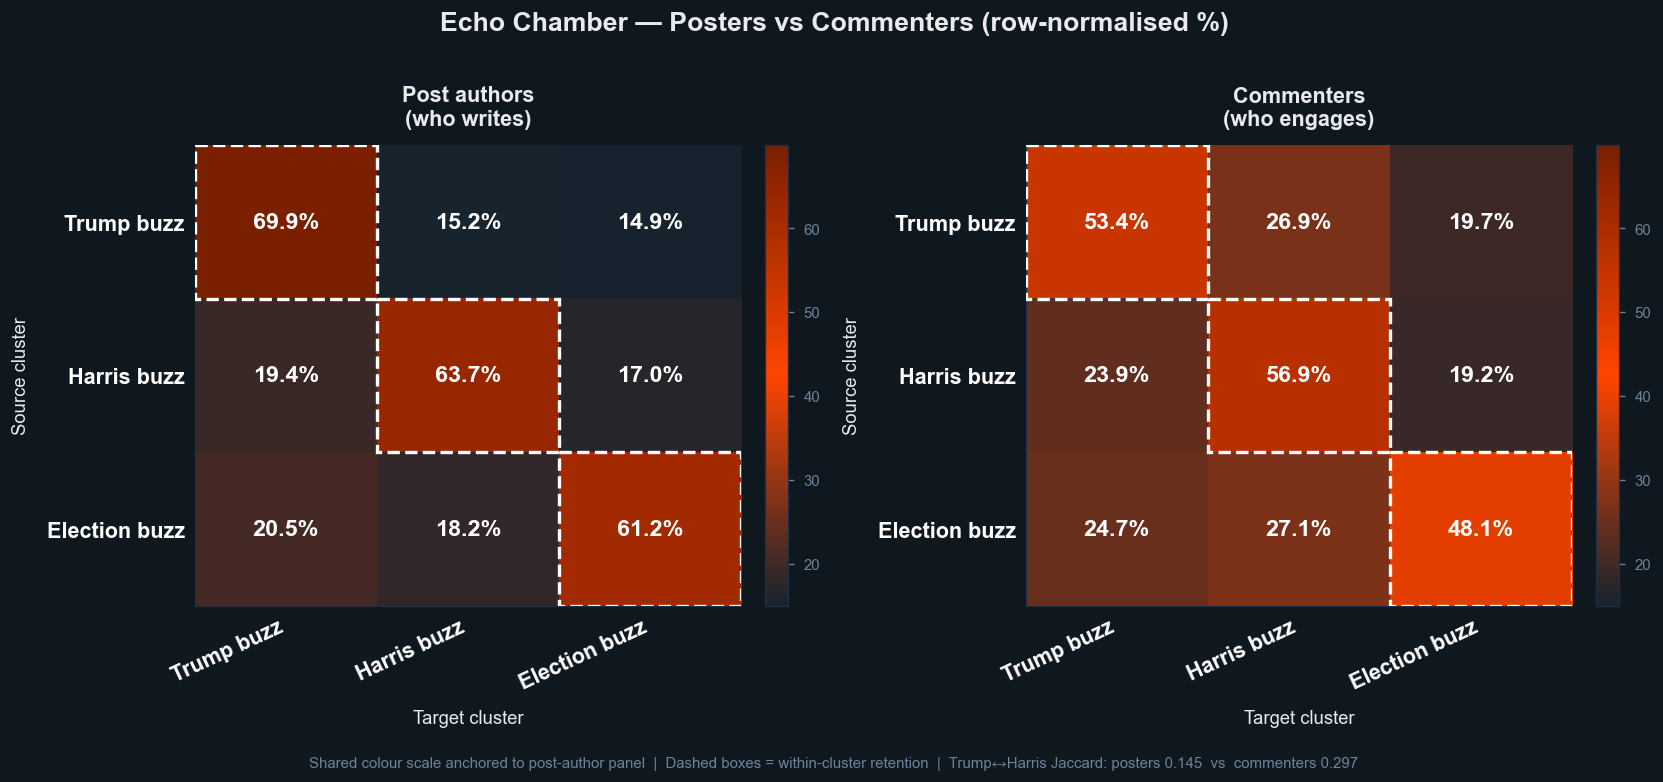

In [49]:
# ── Commenter-based echo chamber ─────────────────────────────────────────────
commenter_buzz = (
    edge_df.groupby('commenter')['post_cand']
    .apply(set)
    .reset_index()
)
commenter_buzz.columns = ['commenter', 'buzz_set']
commenter_buzz['n_clusters'] = commenter_buzz['buzz_set'].apply(len)

print("Commenters by number of distinct buzz clusters engaged with:")
print(commenter_buzz['n_clusters'].value_counts().sort_index().to_string())

# Cross-cluster overlap for commenters
buzz_commenters = {b: set(edge_df[edge_df['post_cand'] == b]['commenter'])
                   for b in buzz_types}

overlap_comm     = np.zeros((3, 3))
raw_overlap_comm = np.zeros((3, 3))
for i, b1 in enumerate(buzz_types):
    for j, b2 in enumerate(buzz_types):
        inter = len(buzz_commenters[b1] & buzz_commenters[b2])
        union = len(buzz_commenters[b1] | buzz_commenters[b2])
        overlap_comm[i, j]     = inter / union if union > 0 else 0
        raw_overlap_comm[i, j] = inter

row_sums_comm    = raw_overlap_comm.sum(axis=1, keepdims=True)
pct_overlap_comm = np.where(row_sums_comm > 0,
                             raw_overlap_comm / row_sums_comm * 100, 0)

trump_harris_poster    = overlap[buzz_types.index('TrumpBuzz'), buzz_types.index('HarrisBuzz')]
trump_harris_commenter = overlap_comm[buzz_types.index('TrumpBuzz'), buzz_types.index('HarrisBuzz')]
delta = trump_harris_commenter - trump_harris_poster
print(f"\nTrump↔Harris Jaccard — posters   : {trump_harris_poster:.3f}")
print(f"Trump↔Harris Jaccard — commenters : {trump_harris_commenter:.3f}")
print(f"Difference                         : {delta:+.3f}  "
      f"({'commenters cross MORE' if delta > 0 else 'commenters cross LESS'})")

# ── Side-by-side: poster vs commenter (row-normalised %) ─────────────────────
# Right panel uses left panel's scale → same colour = same meaning, differences are visible
VMIN, VMAX = pct_overlap.min(), pct_overlap.max()
cmap = mcolors.LinearSegmentedColormap.from_list(
    "reddit", [BG_PANEL, "#FF4500", "#7a1f00"], N=256)

fig, axes = styled_fig(1, 2, figsize=(14, 6),
    title="Echo Chamber — Posters vs Commenters (row-normalised %)")

titles   = ["Post authors\n(who writes)", "Commenters\n(who engages)"]
datasets = [pct_overlap, pct_overlap_comm]

for ax, data, title in zip(axes, datasets, titles):
    im = ax.imshow(data, cmap=cmap, aspect="auto", vmin=VMIN, vmax=VMAX)

    ax.set_xticks(range(3))
    ax.set_xticklabels(buzz_labels, rotation=25, ha='right',
                       color='white', fontsize=13, fontweight='bold')
    ax.set_yticks(range(3))
    ax.set_yticklabels(buzz_labels, color='white', fontsize=13, fontweight='bold')
    ax.set_xlabel("Target cluster", color=TEXT_PRIMARY, fontsize=11, labelpad=10)
    ax.set_ylabel("Source cluster", color=TEXT_PRIMARY, fontsize=11, labelpad=10)
    ax.set_title(title, color=TEXT_PRIMARY, fontsize=13, pad=12)
    ax.tick_params(length=0)
    ax.grid(False)

    for i in range(3):
        for j in range(3):
            val = data[i, j]
            ax.text(j, i, f"{val:.1f}%", ha="center", va="center",
                    color='white', fontsize=14, fontweight="bold")
        ax.add_patch(plt.Rectangle((i - 0.5, i - 0.5), 1, 1,
                                    fill=False, edgecolor='white',
                                    linewidth=2, linestyle="--", zorder=5))

    cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.ax.yaxis.set_tick_params(color=TEXT_MUTED)

fig.text(0.5, -0.03,
         "Shared colour scale anchored to post-author panel  |  Dashed boxes = within-cluster retention  |  "
         f"Trump↔Harris Jaccard: posters {trump_harris_poster:.3f}  vs  "
         f"commenters {trump_harris_commenter:.3f}",
         ha="center", color=TEXT_MUTED, fontsize=9)
plt.tight_layout()
plt.show()

## 7. Summary


In [38]:
print('=' * 55)
print('  REDDIT NETWORK ANALYSIS — SUMMARY')
print('=' * 55)
print()
print(f'  Total posts         : {len(posts):>9,}')
print(f'  Total comments      : {len(comments):>9,}')
print(f'  Unique authors      : {author_subs["author"].nunique():>9,}')
print(f'  Subreddits          : {len(subs):>9}')
print()
print('  Cross-subreddit authors')
print(f'    Active in 1 sub   : {(author_subs["n_subs"] == 1).sum():>9,}')
print(f'    Active in 2+ subs : {(author_subs["n_subs"]  > 1).sum():>9,}')
cross_pct = (author_subs['n_subs'] > 1).mean() * 100
print(f'    Cross-sub rate    : {cross_pct:>8.1f}%')
print()
cp_authors = (author_subs['profile'] == 'Cross-partisan').sum()
cp_pct = cp_authors / len(author_subs) * 100
print(f'  Cross-partisan      : {cp_authors:>9,}  ({cp_pct:.1f}%)')
print()
print('  Keyword network (TF-IDF cosine similarity)')
print(f'    Nodes             : {G_kw.number_of_nodes():>9}')
print(f'    Edges             : {G_kw.number_of_edges():>9}')
print(f'    Density           : {nx.density(G_kw):>9.4f}')
print()
print('  Most central subreddit (PageRank):')
top_pr = max(pr, key=pr.get)
print(f'    r/{top_pr}  ({pr[top_pr]:.4f})')
print()
print('  Echo chamber — cross-cluster Jaccard (Trump vs Harris):')
trump_harris_j = overlap[buzz_types.index('TrumpBuzz'), buzz_types.index('HarrisBuzz')]
print(f'    {trump_harris_j:.4f}  (close to 0 = strong echo chambers)')
print('=' * 55)


  REDDIT NETWORK ANALYSIS — SUMMARY

  Total posts         :   103,008
  Total comments      : 1,321,876
  Unique authors      :   246,084
  Subreddits          :         7

  Cross-subreddit authors
    Active in 1 sub   :   210,982
    Active in 2+ subs :    35,102
    Cross-sub rate    :     14.3%

  Cross-partisan      :     1,917  (0.8%)

  Keyword network (TF-IDF cosine similarity)
    Nodes             :         7
    Edges             :         4
    Density           :    0.1905

  Most central subreddit (PageRank):
    r/politics  (0.3299)

  Echo chamber — cross-cluster Jaccard (Trump vs Harris):
    0.1450  (close to 0 = strong echo chambers)


## Overall Conclusions

| Finding | Evidence |
|---|---|
| **Strong audience segregation** | Near-zero Jaccard overlap between ideologically opposed subreddits |
| **Bridge communities** | r/politics and r/worldnews are the main connectors between left and right communities |
| **Topical echo chambers** | Keyword similarity clusters align with political leaning, not just author co-membership |
| **Buzz cluster insularity** | Very low TrumpBuzz–HarrisBuzz author overlap confirms partisan content consumption |
| **Mostly single-subreddit users** | Majority of authors are active in only one subreddit |
